# データ保存

In [1]:
import os
os.environ["SPEDAS_DATA_DIR"] = "/mnt/j/observation_data/"

# ERGのorbデータから、ERGの速度を算出する。

In [2]:
import pyspedas as psp
import pytplot as pt
import numpy as np
import xarray as xr
import pandas as pd

pt.del_data('*')

time_range = ['20220901/21:00:00', '20220902/00:00:00']
pt.timespan('2022-09-01/22:30:00', 1, keyword='hour')

psp.erg.orb(trange=time_range, level='l2', datatype='def')
psp.erg.mgf(trange=time_range, level='l2', datatype='64hz', coord='gse')

31-Jul-25 16:03:07: del_data: No valid tplot variables found, returning
31-Jul-25 16:03:07: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2022/
31-Jul-25 16:03:08: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf
31-Jul-25 16:03:08: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/mgf/l2/64hz/2022/09/


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


31-Jul-25 16:03:33: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_gse_2022090121_v04.05.cdf
31-Jul-25 16:03:33: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_gse_2022090122_v04.05.cdf
31-Jul-25 16:03:34: File is current: /mnt/j/observation_data//ergsc/satellite/erg/mgf/l2/64hz/2022/09/erg_mgf_l2_64hz_gse_2022090123_v04.05.cdf


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Magnetic Field Experiment (MGF) Level 2 64 Hz resolution magnetic field data']

Information about ERG MGF

PI:  ['Ayako Matsuoka']
Affiliation:  ['Data Analysis Center for Geomagnetism and Space Magnetism, Graduate School of Science, Kyoto University, Kitashirakawa-Oiwake Cho, Sakyo-ku Kyoto 606-8502, Japan']

RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en
RoR of MGF L2: https://ergsc.isee.nagoya-u.ac.jp/mw/index.php/ErgSat/Mgf
Contact: erg_mgf_info at isee.nagoya-u.ac.jp
**************************************************************************


['erg_mgf_l2_epoch_64hz',
 'erg_mgf_l2_date_time_64hz',
 'erg_mgf_l2_mag_64hz_gse',
 'erg_mgf_l2_dyn_rng_64hz',
 'erg_mgf_l2_quality_64hz',
 'erg_mgf_l2_quality_64hz_gc',
 'erg_mgf_l2_spin_phase_64hz',
 'erg_mgf_l2_ti_64hz']

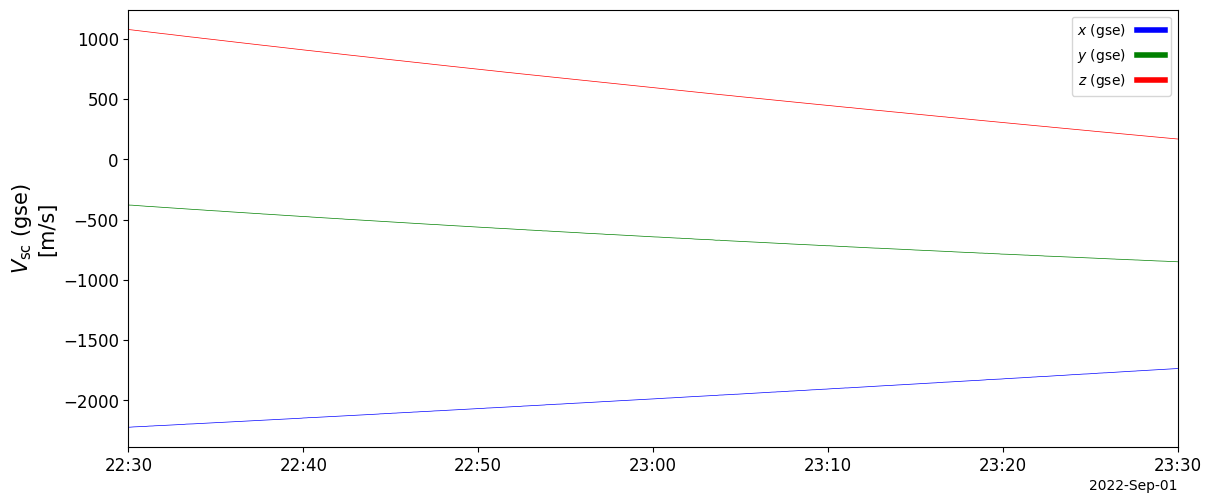

In [28]:
pos = pt.data_quants['erg_orb_l2_pos_gse'].data          # shape (Nt, 3)
t_pos = pt.data_quants['erg_orb_l2_pos_gse'].time.values # numpy.datetime64

R_E_m = 6.378137E6  # [m]

t_sec = t_pos.astype('datetime64[ns]').astype(float) * 1E-9         # epoch 秒
v_sc_gse = np.gradient(pos, t_sec, axis=0) * R_E_m                     # [m/s]

v_sc_gse = xr.DataArray(data=v_sc_gse, dims={'time', 'v_dim'}, coords=dict(time=t_pos), attrs=dict(description=r'$V_{\mathrm{sc}}$ (gse)', units='m/s'))

pt.store_data('v_sc_gse', data={'x': t_sec, 'y': v_sc_gse.data})
pt.options('v_sc_gse', 'char_size', 15)
pt.options('v_sc_gse', 'ytitle', r'$V_{\mathrm{sc}}$ (gse)')
pt.options('v_sc_gse', 'ysubtitle', r'[m/s]')
pt.options('v_sc_gse', 'legend_names', [r'$x$ (gse)', r'$y$ (gse)', r'$z$ (gse)'])
pt.tplot('v_sc_gse')

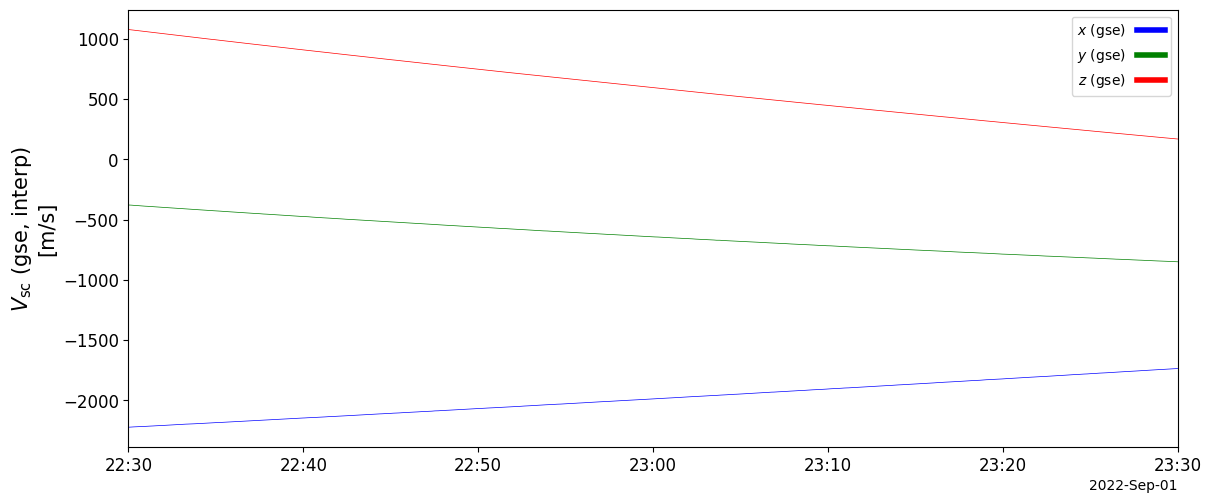

In [30]:
v_sc_gse_interp = v_sc_gse.interp(time=pt.data_quants['erg_mgf_l2_mag_64hz_gse'].time.values, method='linear')

pt.store_data('v_sc_gse_interp', data={'x': v_sc_gse_interp.time, 'y': v_sc_gse_interp.data})
pt.options('v_sc_gse_interp', 'char_size', 15)
pt.options('v_sc_gse_interp', 'ytitle', r'$V_{\mathrm{sc}}$ (gse, interp)')
pt.options('v_sc_gse_interp', 'ysubtitle', r'[m/s]')
pt.options('v_sc_gse_interp', 'legend_names', [r'$x$ (gse)', r'$y$ (gse)', r'$z$ (gse)'])
pt.tplot('v_sc_gse_interp')

31-Jul-25 16:50:59: ['gse', 'gei', 'j2000']
31-Jul-25 16:51:00: Running transformation: subgse2gei
31-Jul-25 16:51:03: Running transformation: subgei2j2000
31-Jul-25 16:51:03: Setting coordinate system for v_sc_j2000
31-Jul-25 16:51:03: Output variable: v_sc_j2000


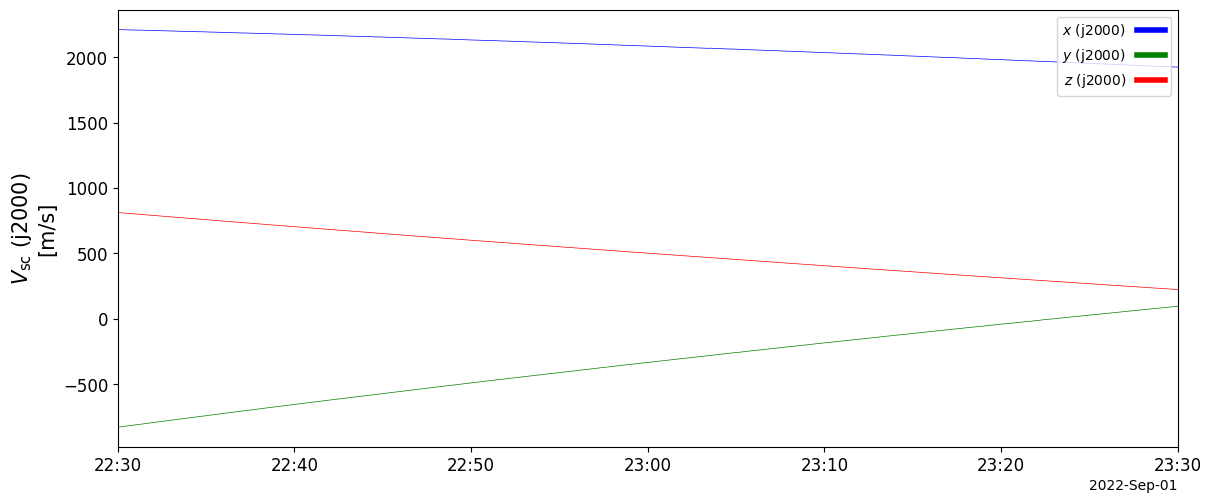

In [32]:
psp.cotrans(name_in='v_sc_gse_interp', name_out='v_sc_j2000', coord_in='gse', coord_out='j2000')

pt.options('v_sc_j2000', 'char_size', 15)
pt.options('v_sc_j2000', 'ytitle', r'$V_{\mathrm{sc}}$ (j2000)')
pt.options('v_sc_j2000', 'ysubtitle', r'[m/s]')
pt.options('v_sc_j2000', 'legend_names', [r'$x$ (j2000)', r'$y$ (j2000)', r'$z$ (j2000)'])
pt.tplot('v_sc_j2000')

31-Jul-25 16:55:16: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/satellite/erg/orb/def/2022/
31-Jul-25 16:55:17: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220901_v05.cdf
31-Jul-25 16:55:17: File is current: /mnt/j/observation_data//ergsc/satellite/erg/orb/def/2022/erg_orb_l2_20220902_v05.cdf
31-Jul-25 16:55:17: tinterpol (linear) was applied to: erg_orb_l2_pos_gse-itrp


 
**************************************************************************
['Exploration of Energization and Radiation in Geospace (ERG) Level-2 orbit data']

Information about ERG orbit


RoR of ERG project common: https://ergsc.isee.nagoya-u.ac.jp/data_info/rules_of_the_road.shtml.en

Contact: erg-sc-core at isee.nagoya-u.ac.jp
**************************************************************************


31-Jul-25 16:55:18: ['gse', 'gei', 'j2000']
31-Jul-25 16:55:19: Running transformation: subgse2gei
31-Jul-25 16:55:22: Running transformation: subgei2j2000
31-Jul-25 16:55:22: Setting coordinate system for sundir_j2000
31-Jul-25 16:55:22: Output variable: sundir_j2000


J2000 --> DSI


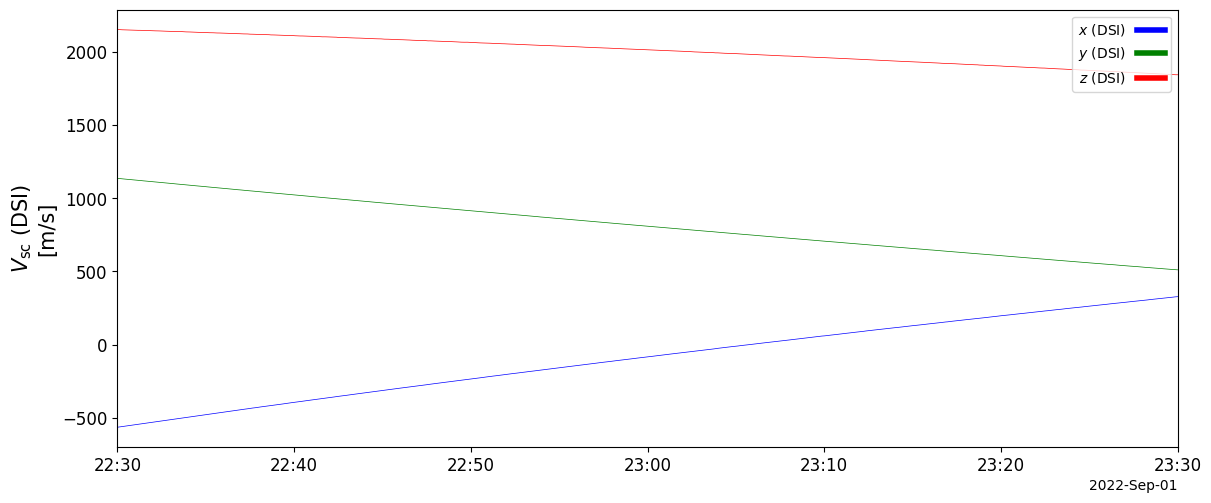

In [35]:
from pyspedas.projects.erg.satellite.erg.common.cotrans.dsi2j2000 import dsi2j2000

dsi2j2000(name_in='v_sc_j2000', name_out='v_sc_dsi', J20002DSI=True)

pt.options('v_sc_dsi', 'char_size', 15)
pt.options('v_sc_dsi', 'ytitle', r'$V_{\mathrm{sc}}$ (DSI)')
pt.options('v_sc_dsi', 'ysubtitle', r'[m/s]')
pt.options('v_sc_dsi', 'legend_names', [r'$x$ (DSI)', r'$y$ (DSI)', r'$z$ (DSI)'])
pt.tplot('v_sc_dsi')